Name:MEHTAB AHMED
StudentID:023-24-0285 
Section: H
GitHub Profile: https://github.com/mehtabahmeddev/MACHINE-LEARNING/tree/8f4ebf4647587ed11b62e415fe1ce0ff596811e4/LAB-06
Kaggle Profile:https://www.kaggle.com/mehtabahmed3201
Dataset information:clean_churn.csv

In [6]:
#1. Load clean_churn.csv (or re-run your Lab 2 cleaning) and verify its shape and dtypes
import pandas as pd

df = pd.read_csv("clean_churn.csv")

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
df.info

Shape: (7032, 20)

Data Types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


<bound method DataFrame.info of       gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7027    Male              0     Yes        Yes      24          Yes   
7028  Female              0     Yes        Yes      72          Yes   
7029  Female              0     Yes        Yes      11           No   
7030    Male              1     Yes         No       4          Yes   
7031    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL       

#Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy, 
precision, recall, F1) — these are your benchmarks for today. 
In Lab 3, the Decision Tree achieved 78.54% accuracy, 61.11% precision, 52.94% recall, and 56.73% F1-score. In Lab 4, the tuned Random Forest achieved 78.89% accuracy, 62.88% precision, 50.27% recall, and 55.87% F1-score.

In [8]:
#. 3Prepare X and y exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1). 
# Task 3

# Task 3

X = df.drop(columns=["Churn"])

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

X = pd.get_dummies(X, drop_first=True, dtype=int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())

X shape: (7032, 30)
y shape: (7032,)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85            0   
1              0      34           56.95       1889.50            1   
2              0       2           53.85        108.15            1   
3              0      45           42.30       1840.75            1   
4              0       2           70.70        151.65            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                               1                  0  ...   
1                               0                  0  ...   
2                               0       

4:n 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for 
the Decision Tree or Random Forest. 
**answer**:Feature scaling is important for KNN because it calculates distance between data points, so features with larger values can dominate the result. Logistic Regression also works better when features are on similar scales. Decision Trees and Random Forests do not depend on distance or feature magnitude, so scaling was not necessary for them.


In [9]:
#task 5:Split into train/test (same split strategy as Lab 3/4), then fit a StandardScaler on the training features only and 
#apply it to both sets. Why is it important to fit the scaler only on the training data?
# Task 5

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (5625, 30)
X_test: (1407, 30)
y_train: (5625,)
y_test: (1407,)


In [10]:
#6. Train a LogisticRegression model on the scaled training data. Generate predictions on the scaled test set.
# Task 6

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

Accuracy: 0.8038379530916845
Precision: 0.6475903614457831
Recall: 0.5748663101604278
F1-score: 0.6090651558073654


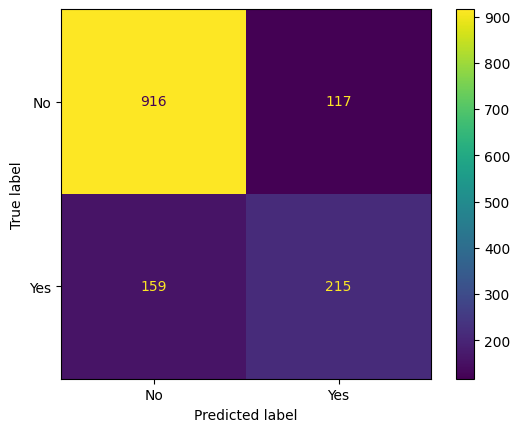

In [11]:
#7: Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix. 
# Task 7

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1-score:", lr_f1)

cm = confusion_matrix(y_test, y_pred_lr)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
).plot()

plt.show()

he Logistic Regression model achieved about 80.38% accuracy. It correctly predicted 916 non-churners and 215 churners, while 159 actual churners were missed and 117 non-churners were incorrectly predicted as churners. The model performs better at identifying non-churners than churners, which is also reflected in the lower recall of 57.49%.

In [12]:
#Look at predict_proba for a handful of test customers. In 1–2 sentences, explain what these probabilities 
#represent and how predict() turns them into a Yes/No decision.
# Task 8

probabilities = lr_model.predict_proba(X_test_scaled[:5])
predictions = lr_model.predict(X_test_scaled[:5])

for i in range(5):
    print("Customer", i + 1)
    print("Probability of No:", probabilities[i][0])
    print("Probability of Yes:", probabilities[i][1])
    print("Prediction:", "Yes" if predictions[i] == 1 else "No")
    print()

Customer 1
Probability of No: 0.9828850540724198
Probability of Yes: 0.017114945927580186
Prediction: No

Customer 2
Probability of No: 0.4038682065493824
Probability of Yes: 0.5961317934506176
Prediction: Yes

Customer 3
Probability of No: 0.9952356756713476
Probability of Yes: 0.0047643243286523565
Prediction: No

Customer 4
Probability of No: 0.7999559177754975
Probability of Yes: 0.20004408222450254
Prediction: No

Customer 5
Probability of No: 0.8997779451547434
Probability of Yes: 0.10022205484525656
Prediction: No



The probabilities show how likely the model thinks each customer is to stay or churn. The `predict()` function normally uses a 0.5 threshold, so if the probability of churn is 0.5 or higher it predicts Yes; otherwise, it predicts No.

In [13]:
#9. Train KNN classifiers for several values of K (e.g. 1, 3, 5, 7, 9, 11, 15, 21) on the scaled data. Record test-set 
#accuracy and F1-score for each K in a results table.

# Task 9

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

k_values = [1, 3, 5, 7, 9, 11, 15, 21]

results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([k, accuracy, f1])

knn_results = pd.DataFrame(
    results,
    columns=["K", "Accuracy", "F1-score"]
)

knn_results

C:\Users\SINDH\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\SINDH\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\SINDH\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\SINDH\AppData\Local\Programs\Python\Pytho

,K,Accuracy,F1-score
0,1,0.724947,0.496749
1,3,0.744136,0.531250
2,5,0.753376,0.535475
3,7,0.749112,0.529960
4,9,0.765458,0.556452
5,11,0.769723,0.558583
6,15,0.771144,0.557692
7,21,0.776830,0.573370


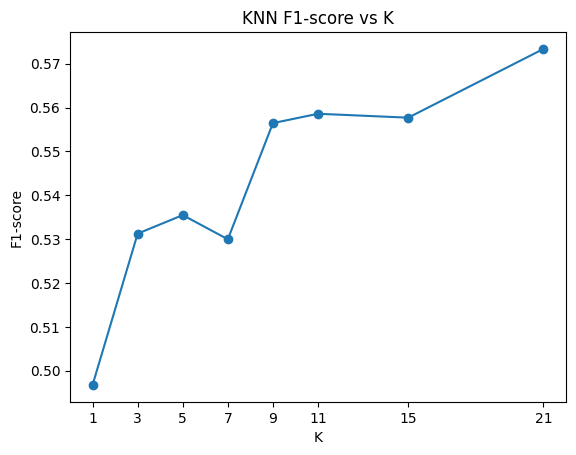

In [15]:
#10 Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest 
#or largest value tested? 
# Task 10

import matplotlib.pyplot as plt

plt.plot(
    knn_results["K"],
    knn_results["F1-score"],
    marker="o"
)

plt.xlabel("K")
plt.ylabel("F1-score")
plt.title("KNN F1-score vs K")
plt.xticks(k_values)

plt.show()

The F1-score generally increases as K increases, with the highest value at K = 21. Therefore, I would choose K = 21 because it gives the best F1-score among the tested values. The smallest K is not preferred because it can overfit to noise, and the largest value should only be chosen if it actually gives the best test performance—which it does here.

Chosen K: 21
Accuracy: 0.7768301350390903
Precision: 0.5828729281767956
Recall: 0.5641711229946524
F1-score: 0.5733695652173914


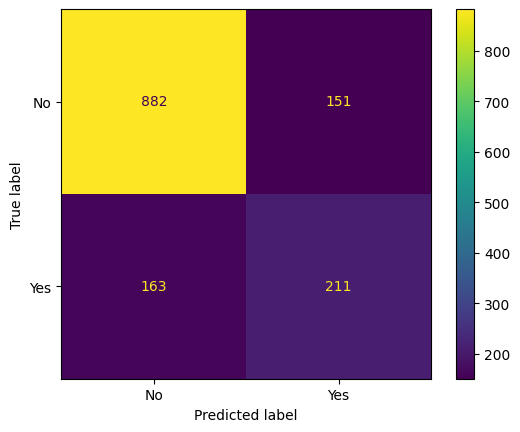

In [18]:
#11:Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for 
#your final KNN model.
# Task 11

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

final_knn = KNeighborsClassifier(n_neighbors=chosen_k)

final_knn.fit(X_train_scaled, y_train)

y_pred_knn = final_knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)

print("Chosen K:", 21)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred_knn)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
).plot()

plt.show()


Using K = 21, I trained the final KNN model and evaluated it using accuracy, precision, recall, F1-score, and the confusion matrix. K = 21 was selected because it gave the highest F1-score among the tested K values.

In [19]:
#12:12. Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision, 
#recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed). 
# Task 12

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "KNN"
    ],
    
    "Accuracy": [
        0.785359,
        0.788913,
        0.803838,
        knn_accuracy
    ],
    
    "Precision": [
        0.611111,
        0.628763,
        0.647590,
        knn_precision
    ],
    
    "Recall": [
        0.529412,
        0.502674,
        0.574866,
        knn_recall
    ],
    
    "F1-score": [
        0.567335,
        0.558692,
        0.609065,
        knn_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.785359,0.611111,0.529412,0.567335
1,Random Forest,0.788913,0.628763,0.502674,0.558692
2,Logistic Regression,0.803838,0.647590,0.574866,0.609065
3,KNN,0.776830,0.582873,0.564171,0.573370


#13
ogistic Regression performs best overall because it has the highest accuracy (0.8038), precision (0.6476), recall (0.5749), and F1-score (0.6091). KNN has the second-highest recall, while Decision Tree has a slightly higher F1-score than Random Forest. So the ranking can change a little depending on which metric is considered. Since the churn dataset is imbalanced, F1-score and recall should be given more importance than accuracy alone, because identifying actual churners is important.

In [20]:
#14. Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation. 
#Interpret at least 4 features (e.g. "customers on this contract type have roughly ___× the odds of churning, 
#holding other features constant")

# Task 14

import numpy as np
import pandas as pd

coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
})

coef_table["Odds Ratio"] = np.exp(coef_table["Coefficient"])

coef_table["Interpretation"] = coef_table.apply(
    lambda row:
    "Increases odds of churn" if row["Odds Ratio"] > 1
    else "Decreases odds of churn",
    axis=1
)

coef_table["Abs_Coefficient"] = abs(coef_table["Coefficient"])

coef_table = coef_table.sort_values(
    "Abs_Coefficient",
    ascending=False
)

coef_table.head(10)

,Feature,Coefficient,Odds Ratio,Interpretation,Abs_Coefficient
1,tenure,-1.347613,0.259860,Decreases odds of churn,1.347613
2,MonthlyCharges,-0.851551,0.426753,Decreases odds of churn,0.851551
10,InternetService_Fiber optic,0.727745,2.070407,Increases odds of churn,0.727745
3,TotalCharges,0.639028,1.894639,Increases odds of churn,0.639028
25,Contract_Two year,-0.602591,0.547392,Decreases odds of churn,0.602591
24,Contract_One year,-0.310898,0.732789,Decreases odds of churn,0.310898
21,StreamingTV_Yes,0.249702,1.283642,Increases odds of churn,0.249702
23,StreamingMovies_Yes,0.236368,1.266641,Increases odds of churn,0.236368
9,MultipleLines_Yes,0.214359,1.239068,Increases odds of churn,0.214359
28,PaymentMethod_Electronic check,0.181473,1.198982,Increases odds of churn,0.181473


In [21]:
top_4 = coef_table.head(4)

top_4[["Feature", "Coefficient", "Odds Ratio", "Interpretation"]]

,Feature,Coefficient,Odds Ratio,Interpretation
1,tenure,-1.347613,0.259860,Decreases odds of churn
2,MonthlyCharges,-0.851551,0.426753,Decreases odds of churn
10,InternetService_Fiber optic,0.727745,2.070407,Increases odds of churn
3,TotalCharges,0.639028,1.894639,Increases odds of churn


#16 Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Part 5 
comparison table and Lab 4's cross-validation lesson about not trusting a single number too much.
**answer**i would select Logistic Regression as the final model because it achieved the highest accuracy (0.8038), precision (0.6476), recall (0.5749), and F1-score (0.6091) in the Part 5 comparison. However, as learned in Lab 4, one train/test split should not be trusted completely, so I would also confirm its performance using cross-validation before making the final deployment decision.

#17 Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model? 
What did feature scaling change? What are the remaining limitations of your best model, and what would you 
try next?
**answer**:logistic Regression was the best model in Lab 6 and performed better than the Decision Tree and Random Forest from Labs 3–4. It achieved the highest accuracy, precision, recall, and F1-score among the four models. Feature scaling was important for Logistic Regression and KNN because these models are affected by differences in feature ranges, while trees did not require scaling. KNN improved as K increased, but its overall performance was still lower than Logistic Regression. One limitation of Logistic Regression is that it assumes a relatively simple linear relationship between the features and churn. The class imbalance can also make it harder to correctly identify churners. Next, I would try cross-validation, class and balancingto improve churn detection